In [45]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [46]:
import pandas as pd

In [47]:
ROOT = "./"

training_set = pd.read_csv(ROOT + "Training and Testing Sets/" + "UNSW_NB15_training-set.csv")
testing_set = pd.read_csv(ROOT + "Training and Testing Sets/" + "UNSW_NB15_testing-set.csv")

print(training_set.head())
print(testing_set.head())

print(f"Value counts labels : {testing_set['label'].value_counts()}")
print(f"Value counts labels : {training_set['label'].value_counts()}")

# print number of normal for feature attack_cat
print(f"Value counts attack_cat : {testing_set['attack_cat'].value_counts()}")
print(f"Value counts attack_cat : {training_set['attack_cat'].value_counts()}")

# Drop the 'id' column if it exists
training_set = training_set.drop(columns=['id'], errors='ignore')
testing_set = testing_set.drop(columns=['id'], errors='ignore')

# Print all the columns in the dataset
print(f"Columns in training set: {training_set.columns.tolist()}")
print(f"Columns in testing set: {testing_set.columns.tolist()}")

print(training_set.shape)
print(testing_set.shape)

   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3   4  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4   5  0.449454   tcp       -   FIN     10      6     534     268  33.373826   

   ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0  ...                 1               1             0           0   
1  ...                 1               2             0           0   
2  ...                 1               3             0           0   
3  ...                 1               3             1           1   
4  ...                 1              40             0           0   

   ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  attack_cat  \
0                 0   

In [48]:
from sklearn.preprocessing import StandardScaler

# Preprocessing the data

training_set_processed = training_set.copy()
testing_set_processed = testing_set.copy()

training_missing_values = training_set_processed.isnull().sum().sum()
testing_missing_values = testing_set_processed.isnull().sum().sum()
print(f"Number of missing values in training set: {training_missing_values}")
print(f"Number of missing values in testing set: {testing_missing_values}")

training_set_processed = training_set_processed.dropna()
testing_set_processed = testing_set_processed.dropna()
print(f"Number of missing values after dropping: {training_set_processed.isnull().sum().sum()}")
print(f"Number of missing values after dropping: {testing_set_processed.isnull().sum().sum()}")

# Normalize the data

# Standardize features
scaler = StandardScaler()

# Standardize training dataset
feature_cols = training_set_processed.columns.drop(["attack_cat", "label"])
numerical_cols = training_set_processed[feature_cols].select_dtypes(include=["number"]).columns

# Show statistics before scaling
print(f"Original features shape: {training_set_processed[numerical_cols].shape}")
print(f"Before scaling (first feature):")
print(f"\tMean: {training_set_processed[numerical_cols[0]].mean():.4f}")
print(f"\tStd:  {training_set_processed[numerical_cols[0]].std():.4f}")
print(f"\tMin:  {training_set_processed[numerical_cols[0]].min():.4f}")
print(f"\tMax:  {training_set_processed[numerical_cols[0]].max():.4f}")

training_set_processed[numerical_cols] = scaler.fit_transform(training_set_processed[numerical_cols])

# Show statistics after scaling
print(f"\nScaled features shape: {training_set_processed[numerical_cols].shape}")
print(f"After scaling (first feature):")
print(f"\tMean: {training_set_processed[numerical_cols].iloc[:, 0].mean():.4f}")
print(f"\tStd:  {training_set_processed[numerical_cols].iloc[:, 0].std():.4f}")
print(f"\tMin:  {training_set_processed[numerical_cols].iloc[:, 0].min():.4f}")
print(f"\tMax:  {training_set_processed[numerical_cols].iloc[:, 0].max():.4f}")


# Standardize Wednesday dataset
feature_cols = testing_set_processed.columns.drop(["attack_cat", "label"])
numerical_cols = testing_set_processed[feature_cols].select_dtypes(include=["number"]).columns
# Show statistics before scaling
print(f"Original features shape: {testing_set_processed[numerical_cols].shape}")
print(f"Before scaling (first feature):")
print(f"\tMean: {testing_set_processed[numerical_cols[0]].mean():.4f}")
print(f"\tStd:  {testing_set_processed[numerical_cols[0]].std():.4f}")
print(f"\tMin:  {testing_set_processed[numerical_cols[0]].min():.4f}")
print(f"\tMax:  {testing_set_processed[numerical_cols[0]].max():.4f}")

testing_set_processed[numerical_cols] = scaler.fit_transform(testing_set_processed[numerical_cols])

# Show statistics after scaling
print(f"\nScaled features shape: {testing_set_processed[numerical_cols].shape}")
print(f"After scaling (first feature):")
print(f"\tMean: {testing_set_processed[numerical_cols].iloc[:, 0].mean():.4f}")
print(f"\tStd:  {testing_set_processed[numerical_cols].iloc[:, 0].std():.4f}")
print(f"\tMin:  {testing_set_processed[numerical_cols].iloc[:, 0].min():.4f}")
print(f"\tMax:  {testing_set_processed[numerical_cols].iloc[:, 0].max():.4f}")

Number of missing values in training set: 0
Number of missing values in testing set: 0
Number of missing values after dropping: 0
Number of missing values after dropping: 0
Original features shape: (175341, 39)
Before scaling (first feature):
	Mean: 1.3594
	Std:  6.4802
	Min:  0.0000
	Max:  60.0000

Scaled features shape: (175341, 39)
After scaling (first feature):
	Mean: -0.0000
	Std:  1.0000
	Min:  -0.2098
	Max:  9.0492
Original features shape: (82332, 39)
Before scaling (first feature):
	Mean: 1.0068
	Std:  4.7104
	Min:  0.0000
	Max:  60.0000

Scaled features shape: (82332, 39)
After scaling (first feature):
	Mean: -0.0000
	Std:  1.0000
	Min:  -0.2137
	Max:  12.5240


# 1. Comparative Security Modeling

## 1.1 Binary Intrusion Detection

In [49]:
X_train_bin = training_set_processed.drop(columns=["attack_cat", "label"])
y_train_bin = training_set_processed["label"]

X_test_bin = testing_set_processed.drop(columns=["attack_cat", "label"])
y_test_bin = testing_set_processed["label"]

In [50]:
print(f"Unique values in y_train_bin: {y_train_bin.unique()}")
print(f"Value counts in y_train_bin: {y_train_bin.value_counts()}")
print(f"Value counts in y_test_bin: {y_test_bin.value_counts()}")

# One hot encoding for all categorical features
X_train_bin = pd.get_dummies(X_train_bin)
X_test_bin = pd.get_dummies(X_test_bin)

print(X_train_bin.head())

# Aligner le set de validation sur le train
# On ajoute les colonnes manquantes (remplies de 0) et on supprime les colonnes en trop
X_test_bin = X_test_bin.reindex(columns=X_train_bin.columns, fill_value=False)

print(X_train_bin.head())
print(X_test_bin.head())

# Check values in label encoded
print(f"Unique values in y_train_bin: {y_train_bin.unique()}")
print(f"Unique values in y_test_bin: {y_test_bin.unique()}")
# check which value corresponds to attack and which to normal
print(f"Value counts in y_train_bin: {y_train_bin.value_counts()}")
print(f"Value counts in y_test_bin: {y_test_bin.value_counts()}")


Unique values in y_train_bin: [0 1]
Value counts in y_train_bin: label
1    119341
0     56000
Name: count, dtype: int64
Value counts in y_test_bin: label
1    45332
0    37000
Name: count, dtype: int64
        dur     spkts     dpkts    sbytes    dbytes      rate      sttl  \
0 -0.191029 -0.104456 -0.135769 -0.049134 -0.102726 -0.576371  0.703839   
1 -0.109485 -0.046014  0.172599 -0.046410  0.188544 -0.576345 -1.141901   
2  0.040699 -0.089845 -0.026933 -0.048527 -0.012133 -0.576734 -1.141901   
3  0.049729 -0.060624 -0.063212 -0.047016 -0.098563 -0.576737 -1.141901   
4 -0.140417 -0.075235 -0.117630 -0.047554 -0.102057 -0.576617  0.723268   

       dttl     sload     dload  ...  service_ssl  state_CON  state_ECO  \
0  1.578100 -0.389897 -0.273700  ...        False      False      False   
1  1.560002 -0.389928 -0.069233  ...        False      False      False   
2  1.560002 -0.389964 -0.252044  ...        False      False      False   
3  1.560002 -0.389958 -0.275821  ...        Fa

### Tuning XGBClassifier

In [51]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
import time

In [52]:
params = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.001, 0.005, 0.01, 0.05],
    'max_depth': [1, 2, 3, 5]
}

from scipy.stats import uniform, randint

p_grid = {
        "n_estimators": randint(100, 1000),
        "colsample_bytree": uniform(0.7, 0.3),
        "gamma": uniform(0, 0.5),
        "learning_rate": uniform(0.03, 0.3),
        "max_depth": randint(2, 8),        
        "subsample": uniform(0.6, 0.4)
}

start_time = time.time()

# bin_gs = GridSearchCV(XGBClassifier(n_jobs=-1, 
#                                     objective='binary:logistic', 
#                                     eval_metric='logloss'), 
#                         p_grid, 
#                         n_jobs=-1, 
#                         cv=3, 
#                         scoring='f1', 
#                         verbose=3)

bin_gs = RandomizedSearchCV(XGBClassifier(n_jobs=-1, 
                                    objective='binary:logistic', 
                                    eval_metric='logloss'), 
                        p_grid, 
                        n_jobs=-1, 
                        cv=3, 
                        scoring='f1', 
                        verbose=3,
                        n_iter=10)


bin_gs.fit(X_train_bin, y_train_bin)

end_time = time.time()

print('Best score:', bin_gs.best_score_)
print('Best params:', bin_gs.best_params_)
print(f"Time taken for grid search: {(end_time - start_time)/60:.1f} minutes")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best score: 0.9291305048719783
Best params: {'colsample_bytree': np.float64(0.9144650654769764), 'gamma': np.float64(0.3539889218069383), 'learning_rate': np.float64(0.14044669768000104), 'max_depth': 5, 'n_estimators': 434, 'subsample': np.float64(0.7815942970583394)}
Time taken for grid search: 1.5 minutes


### Predictions

In [53]:
### https://xgboost.readthedocs.io/en/release_3.2.0/get_started.html

# Best parameters from last run: (0.9291305048719783 score)
# colsample_bytree= 0.91,
# gamma= 0.35,
# learning_rate= 0.14,
# max_depth= 5,
# n_estimators= 434,
# subsample= 0.78,

from xgboost import XGBClassifier

# create model instance
bin_bst = XGBClassifier(# tuned
                        colsample_bytree= 0.91,
                        gamma= 0.35,
                        learning_rate= 0.14,
                        max_depth= 5,
                        n_estimators= 434,
                        subsample= 0.78,
                        # default
                        use_label_encoder= False,
                        booster= 'gbtree',
                        importance_type= 'gain',
                        objective='binary:logistic',
                        eval_metric='logloss',
                        n_jobs=-1,
    )

# fit model
bin_bst.fit(X_train_bin, y_train_bin)
# make predictions
bin_preds = bin_bst.predict(X_test_bin)
#y_proba = bin_bst.predict_proba(X_test_bin)[:, 1]

c:\Users\ianis\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:27:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Target names: [0 1]


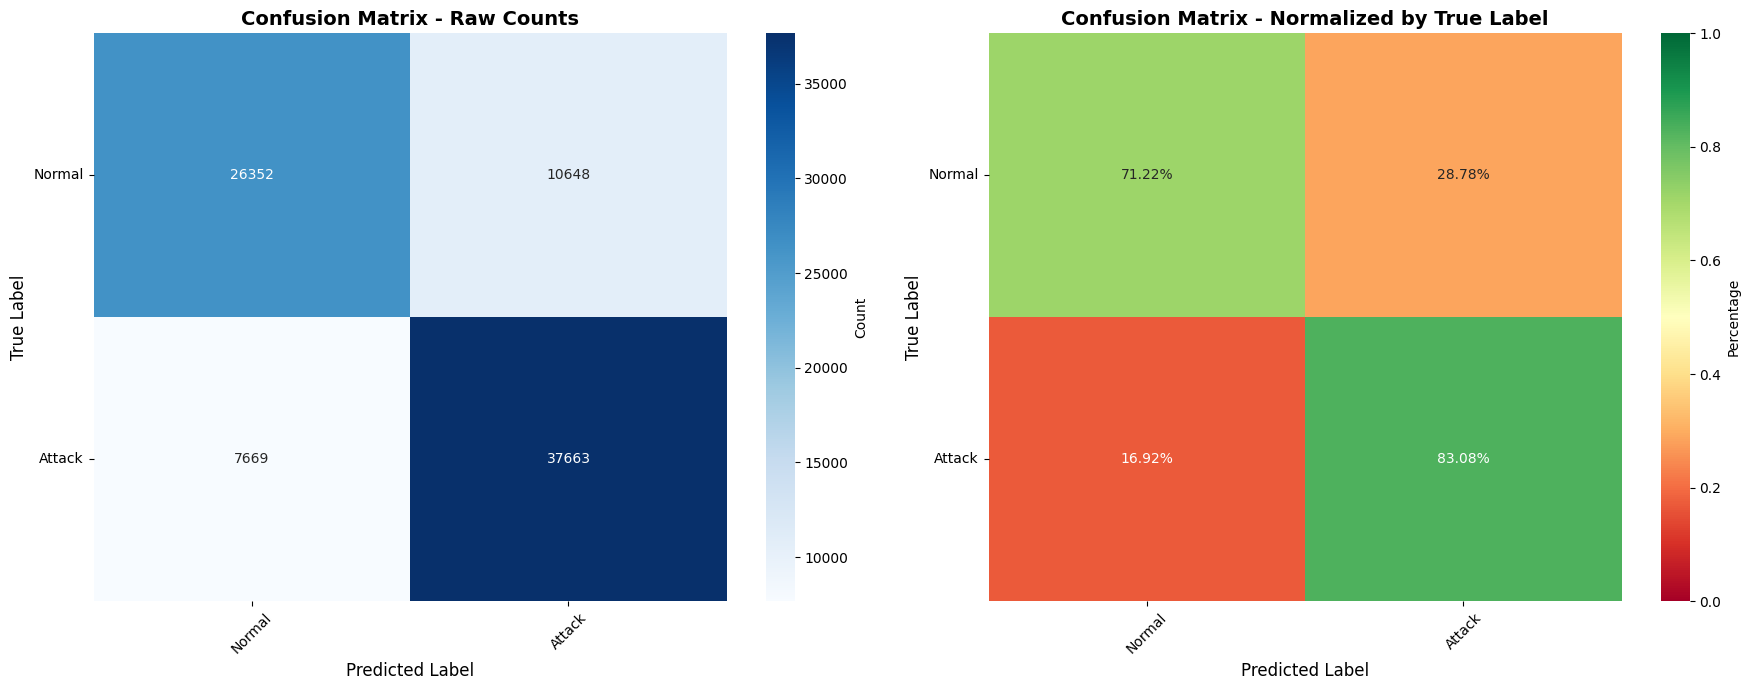

In [54]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
bin_target_names = ['Normal', 'Attack']
# Check if the target names are correct
print(f"Target names: {testing_set_processed['label'].unique()}")

bin_cm = confusion_matrix(y_test_bin, bin_preds)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw counts
sns.heatmap(bin_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=bin_target_names, yticklabels=bin_target_names,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Normalized (percentage per true class)
bin_cm_normalized = bin_cm.astype('float') / bin_cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(bin_cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=bin_target_names, yticklabels=bin_target_names,
            cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix - Normalized by True Label', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


In [55]:
# Precision, Recall, F1-score
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

bin_target_names = ['Normal', 'Attack']

## Performance metrics
print("Accuracy:", accuracy_score(y_test_bin, bin_preds))
print("\nClassification Report:\n",
      classification_report(y_test_bin, bin_preds, target_names=bin_target_names))

Accuracy: 0.7775227129184278

Classification Report:
               precision    recall  f1-score   support

      Normal       0.77      0.71      0.74     37000
      Attack       0.78      0.83      0.80     45332

    accuracy                           0.78     82332
   macro avg       0.78      0.77      0.77     82332
weighted avg       0.78      0.78      0.78     82332



In [56]:
# False Positive Rate (FPR) and False Negative Rate (FNR)

tn, fp, fn, tp = bin_cm.ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"False Positive Rate (FPR): {fpr:.2f}")
print(f"False Negative Rate (FNR): {fnr:.2f}")

False Positive Rate (FPR): 0.29
False Negative Rate (FNR): 0.17


## 1.2 Class Attack Category Classification

In [57]:
X_train_class = training_set.drop(columns=["attack_cat", "label"])
y_train_class = training_set["attack_cat"]

X_test_class = testing_set.drop(columns=["attack_cat", "label"])
y_test_class = testing_set["attack_cat"]

attack_classes_names = y_train_class.unique()
print(attack_classes_names)

# Replace attack category names with numeric labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_class_encoded = le.fit_transform(y_train_class)
y_test_class_encoded = le.transform(y_test_class)


<StringArray>
[        'Normal',       'Backdoor',       'Analysis',        'Fuzzers',
      'Shellcode', 'Reconnaissance',       'Exploits',            'DoS',
          'Worms',        'Generic']
Length: 10, dtype: str


In [58]:
# One hot encoding for all categorical features
X_train_class = pd.get_dummies(X_train_class)
X_test_class = pd.get_dummies(X_test_class)

print(X_train_class.head())

# Aligner le set de validation sur le train
# On ajoute les colonnes manquantes (remplies de 0) et on supprime les colonnes en trop
X_test_class = X_test_class.reindex(columns=X_train_class.columns, fill_value=False)

#print(X_train_class.head())
#print(X_test_class.head())

        dur  spkts  dpkts  sbytes  dbytes       rate  sttl  dttl  \
0  0.121478      6      4     258     172  74.087490   252   254   
1  0.649902     14     38     734   42014  78.473372    62   252   
2  1.623129      8     16     364   13186  14.170161    62   252   
3  1.681642     12     12     628     770  13.677108    62   252   
4  0.449454     10      6     534     268  33.373826   254   252   

          sload          dload  ...  service_ssl  state_CON  state_ECO  \
0  14158.942380    8495.365234  ...        False      False      False   
1   8395.112305  503571.312500  ...        False      False      False   
2   1572.271851   60929.230470  ...        False      False      False   
3   2740.178955    3358.622070  ...        False      False      False   
4   8561.499023    3987.059814  ...        False      False      False   

   state_FIN  state_INT  state_PAR  state_REQ  state_RST  state_URN  state_no  
0       True      False      False      False      False      Fals

### Tuning Multi-classifier

In [59]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import time

In [60]:
params = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.005, 0.01, 0.05, 0.1],
    'max_depth': [1, 2, 3, 4, 5]
}


p_grid = {
        "n_estimators": randint(100, 1000),
        "colsample_bytree": uniform(0.7, 0.3),
        "gamma": uniform(0, 0.5),
        "learning_rate": uniform(0.03, 0.3),
        "max_depth": randint(2, 8),        
        "subsample": uniform(0.6, 0.4)
}

start_time = time.time()

class_gs = RandomizedSearchCV(
                XGBClassifier(n_jobs=-1, 
                              objective='multi:softprob', 
                              eval_metric='mlogloss'), 
                p_grid, 
                n_jobs=-1, 
                cv=3, 
                n_iter=10,
                scoring='f1_macro', 
                verbose=3)
class_gs.fit(X_train_class, y_train_class_encoded)

end_time = time.time()

print('Best score:', class_gs.best_score_)
print('Best params:', class_gs.best_params_)
print(f"Time taken for grid search: {(end_time - start_time)/60:.1f} minutes")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best score: 0.5728126137547193
Best params: {'colsample_bytree': np.float64(0.8196784604616515), 'gamma': np.float64(0.19027941377711505), 'learning_rate': np.float64(0.2476206052417021), 'max_depth': 3, 'n_estimators': 389, 'subsample': np.float64(0.6819142365677715)}
Time taken for grid search: 13.0 minutes


### Predictions

In [61]:
# Best parameters from last run: (0.5728126137547193 score)
# 'colsample_bytree': 0.82, 
# 'gamma': 0.19, 
# 'learning_rate': 0.25, 
# 'max_depth': 3, 
# 'n_estimators': 389, 
# 'subsample': 0.68


# Multi-class classification with XGBoost

from xgboost import XGBClassifier

# create model instance
class_bst = XGBClassifier(# tuned
                          colsample_bytree= 0.82,
                          gamma= 0.19,
                          learning_rate= 0.25,
                          max_depth= 3,
                          n_estimators= 389,
                          subsample= 0.68,
                          # default
                          use_label_encoder= False,
                          booster= 'gbtree',
                          importance_type= 'gain', 
                          objective='multi:softprob', 
                          num_class=len(le.classes_), 
                          eval_metric='mlogloss')
# fit model
class_bst.fit(X_train_class, y_train_class_encoded)
# make predictions
class_preds = class_bst.predict(X_test_class)

c:\Users\ianis\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:44:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']


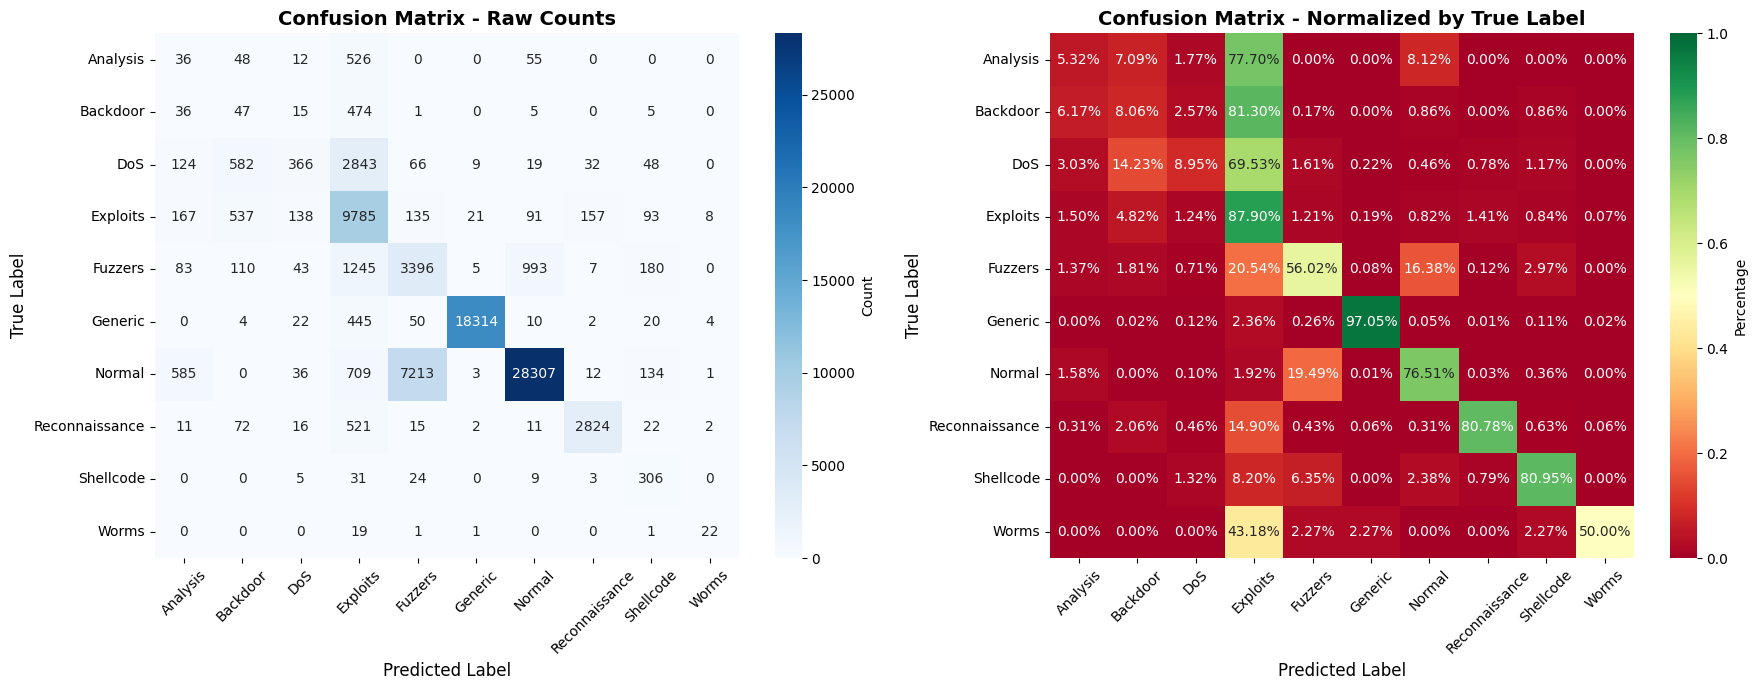

In [62]:
# Multiclass confusion matrix

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
class_target_names = le.classes_
print(class_target_names)

class_cm = confusion_matrix(y_test_class_encoded, class_preds)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw counts
sns.heatmap(class_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_target_names, yticklabels=class_target_names,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Normalized (percentage per true class)
class_cm_normalized = class_cm.astype('float') / class_cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(class_cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=class_target_names, yticklabels=class_target_names,
            cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix - Normalized by True Label', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


In [63]:
# Per-class recall and F1-score

from sklearn.metrics import classification_report
class_target_names = le.classes_
print("Classification Report:\n",
      classification_report(y_test_class_encoded, class_preds, target_names=class_target_names))

Classification Report:
                 precision    recall  f1-score   support

      Analysis       0.03      0.05      0.04       677
      Backdoor       0.03      0.08      0.05       583
           DoS       0.56      0.09      0.15      4089
      Exploits       0.59      0.88      0.71     11132
       Fuzzers       0.31      0.56      0.40      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.96      0.77      0.85     37000
Reconnaissance       0.93      0.81      0.86      3496
     Shellcode       0.38      0.81      0.52       378
         Worms       0.59      0.50      0.54        44

      accuracy                           0.77     82332
     macro avg       0.54      0.55      0.51     82332
  weighted avg       0.83      0.77      0.78     82332



# 2. Context-Aware Feature Semantics 

## 2.2 Attack Behavior Profiling

Stats for category: DoS
Number of samples: 12264

----- Load features: -----
sload:
  mean ± std: 126281382.6454 ± 178605855.6631
  median: 88888888.0000
  95th percentile: 400000000.0000
dload:
  mean ± std: 15009.7586 ± 111400.4462
  median: 0.0000
  95th percentile: 25356.4177

----- Packet features: -----
spkts:
  mean ± std: 22.5246 ± 230.9942
  median: 2.0000
  95th percentile: 42.0000
dpkts:
  mean ± std: 18.6890 ± 277.0316
  median: 0.0000
  95th percentile: 20.0000

----- Duration: -----
dur:
  mean ± std: 2.5749 ± 10.4392
  median: 0.0000
  95th percentile: 12.6026

----- Service usage: -----


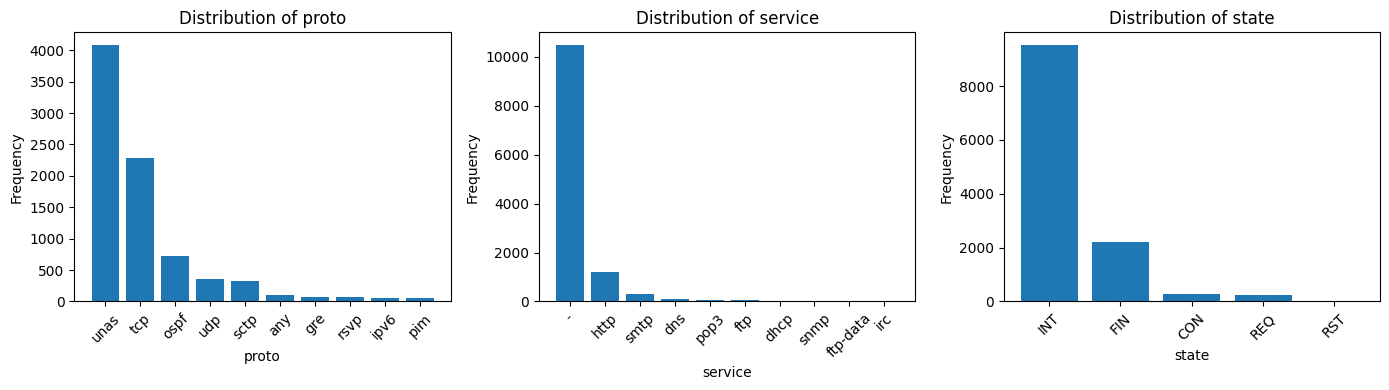

--------------------------------------------------

Stats for category: Exploits
Number of samples: 33393

----- Load features: -----
sload:
  mean ± std: 65310277.4090 ± 159777894.0927
  median: 29487.1699
  95th percentile: 266666656.0000
dload:
  mean ± std: 53272.9959 ± 181154.4969
  median: 3664.3191
  95th percentile: 333712.8500

----- Packet features: -----
spkts:
  mean ± std: 32.7175 ± 266.6658
  median: 10.0000
  95th percentile: 68.0000
dpkts:
  mean ± std: 22.1618 ± 106.2549
  median: 8.0000
  95th percentile: 62.0000

----- Duration: -----
dur:
  mean ± std: 2.2586 ± 7.8429
  median: 0.4865
  95th percentile: 6.2796

----- Service usage: -----


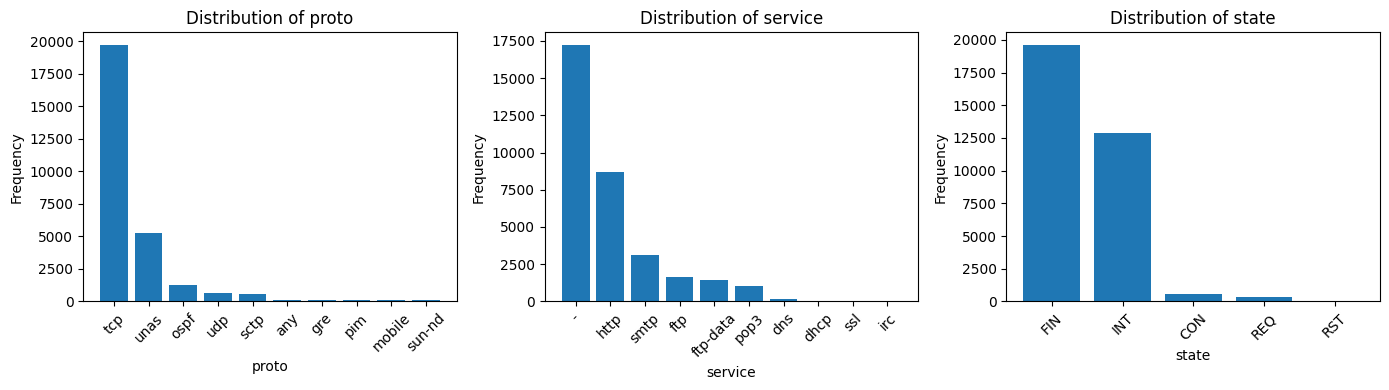

--------------------------------------------------

Stats for category: Reconnaissance
Number of samples: 10491

----- Load features: -----
sload:
  mean ± std: 73682736.3579 ± 126687364.0671
  median: 33017.7734
  95th percentile: 266666656.0000
dload:
  mean ± std: 2384.2411 ± 25884.7582
  median: 0.0000
  95th percentile: 5958.8137

----- Packet features: -----
spkts:
  mean ± std: 7.0571 ± 16.4019
  median: 10.0000
  95th percentile: 10.0000
dpkts:
  mean ± std: 5.2765 ± 81.9378
  median: 0.0000
  95th percentile: 8.0000

----- Duration: -----
dur:
  mean ± std: 1.0601 ± 5.1986
  median: 0.1873
  95th percentile: 1.9471

----- Service usage: -----


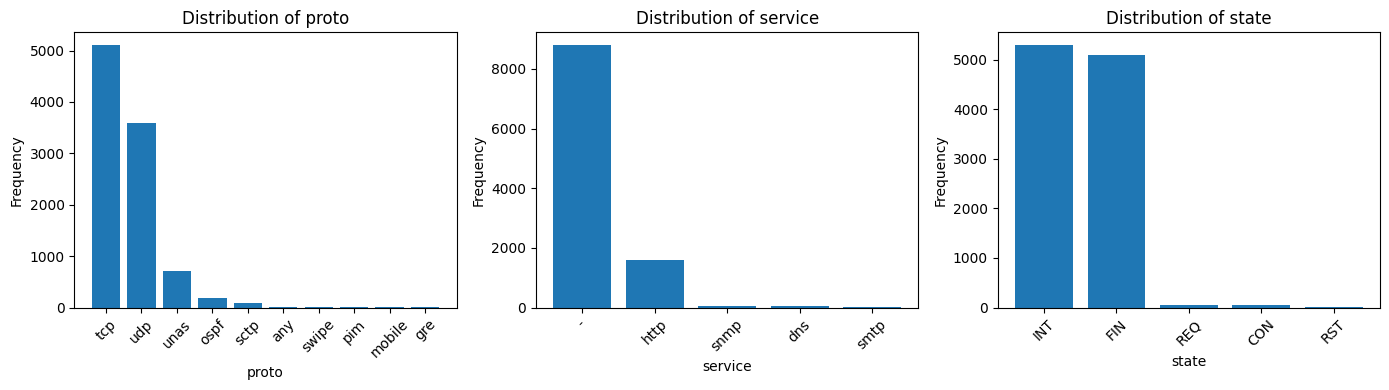

--------------------------------------------------

Stats for category: Normal
Number of samples: 56000

----- Load features: -----
sload:
  mean ± std: 23170702.7308 ± 151427436.4534
  median: 431327.6562
  95th percentile: 45000000.0000
dload:
  mean ± std: 2062949.2437 ± 3935216.8205
  median: 336120.6406
  95th percentile: 12726090.1500

----- Packet features: -----
spkts:
  mean ± std: 30.7255 ± 57.3441
  median: 12.0000
  95th percentile: 108.0000
dpkts:
  mean ± std: 38.0577 ± 105.7733
  median: 10.0000
  95th percentile: 114.0000

----- Duration: -----
dur:
  mean ± std: 1.0172 ± 4.8592
  median: 0.0386
  95th percentile: 2.3881

----- Service usage: -----


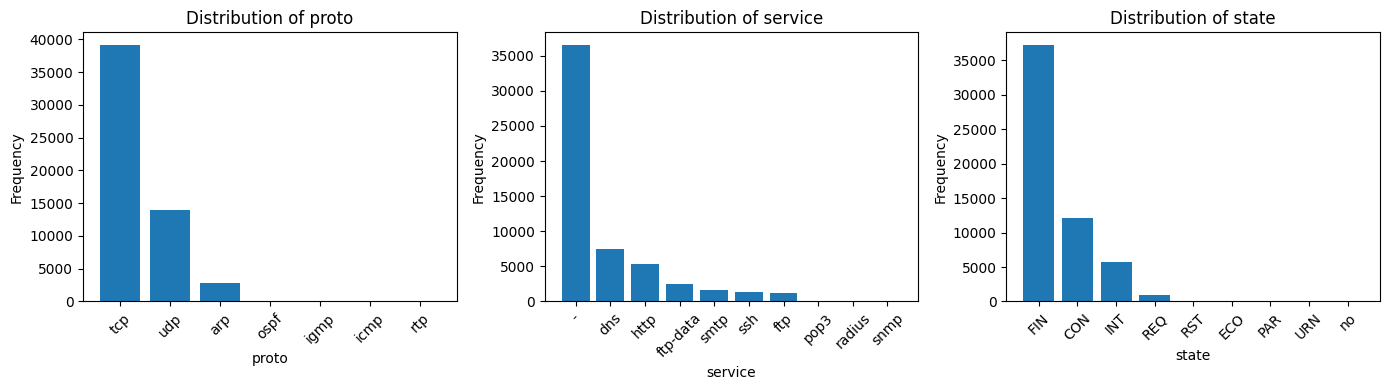

--------------------------------------------------



In [64]:
load_features = ["sload", "dload"]
packet_features = ["spkts", "dpkts"]
duration_features = ["dur", "stime", "ltime"]
service_usage_features = ["proto", "service", "state"]

# Helping function to print statistics for a given set of features and a dataset
def print_stats(features, dataset, title):
    print(f"\n----- {title}: -----")
    for col in features:
        if col in dataset.columns:
            print(f"{col}:")
            print(f"  mean ± std: {dataset[col].mean():.4f} ± {dataset[col].std():.4f}")
            print(f"  median: {dataset[col].median():.4f}")
            print(f"  95th percentile: {dataset[col].quantile(0.95):.4f}")

def stats_for_category(category_name):
    
    # We took the training set, as it is the one we train on
    restricted_set = training_set.copy()
    restricted_set = restricted_set[restricted_set['attack_cat'] == category_name]

    print (f"Stats for category: {category_name}")
    print(f"Number of samples: {restricted_set.shape[0]}")

    # Load features 
    print_stats(load_features, restricted_set, "Load features")

    # Packet features
    print_stats(packet_features, restricted_set, "Packet features")

    # Duration
    print_stats(duration_features, restricted_set, "Duration")

    # Service usage
    print("\n----- Service usage: -----")
    plt.figure(figsize=(14, 4))

    for i, col in enumerate(service_usage_features):
        if col in restricted_set.columns:
            plt.subplot(1, 3, i + 1)

            counts = restricted_set[col].value_counts().head(10)  # Get top 10 most common values

            plt.bar(counts.index, counts.values)
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.title(f'Distribution of {col}')
            plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    print("-" * 50 + "\n")


# Test

stats_for_category("DoS")

stats_for_category("Exploits")

stats_for_category("Reconnaissance")

# Just to check

stats_for_category("Normal")


# 3. Misclassification and Security Error Analysis

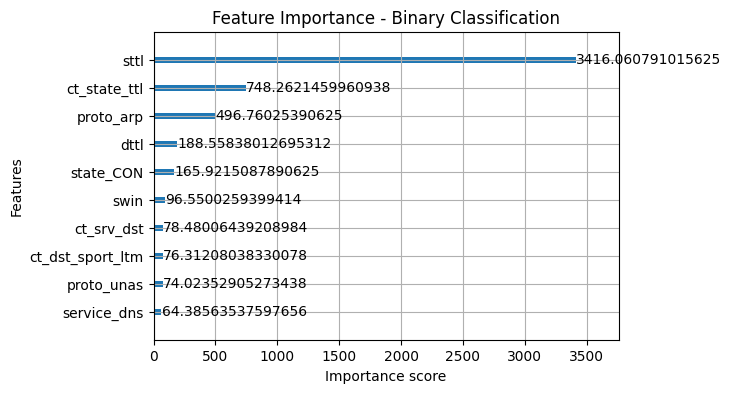

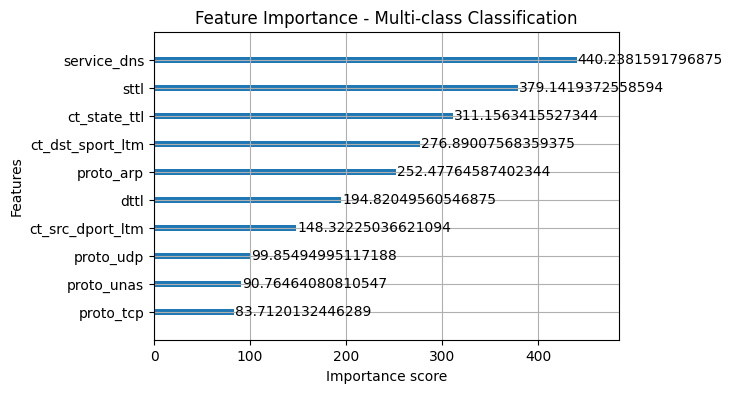

In [65]:
from xgboost import plot_importance

# Overall feature importance for binary classification

plot_importance(bin_bst, importance_type='gain', max_num_features=10, title='Feature Importance - Binary Classification')
plt.rcParams['figure.figsize'] = [6, 4]
plt.show()

# Overall feature importance for multi-class classification

plot_importance(class_bst, importance_type='gain', max_num_features=10, title='Feature Importance - Multi-class Classification')
plt.rcParams['figure.figsize'] = [6, 4]
plt.show()    

## 3.1 Misclassification and Security Error Analysis

In [66]:
# Identify attack samples classified as normal

bin_false_negatives = (y_test_bin == 1) & (bin_preds == 0)
print(f"Number of attack samples classified as normal: {bin_false_negatives.sum()}")
bin_false_negatives_index = bin_false_negatives[bin_false_negatives].index

Number of attack samples classified as normal: 7669


In [67]:
# Examples of false negatives
print("----- Examples of false negatives: -----")

index1 = bin_false_negatives_index[8]
index2 = bin_false_negatives_index[600]
index3 = bin_false_negatives_index[1534]
index4 = bin_false_negatives_index[2000]
index5 = bin_false_negatives_index[2500]
index6 = bin_false_negatives_index[3000]

# print(y_test_class.loc[bin_false_negatives_index].head(50))

# We chose these 3 indices as examples
print(f"Index of false negative examples: {index1}, {index2}, {index3}, {index4}, {index5}, {index6}\n")

print(testing_set.loc[[index1, index2, index3, index4, index5, index6]])

----- Examples of false negatives: -----
Index of false negative examples: 278, 2667, 8683, 9831, 11018, 19841

            dur proto service state  spkts  dpkts  sbytes  dbytes        rate  \
278    2.032866   tcp     ftp   FIN     22     22    1186    1602   21.152403   
2667   0.679643   tcp    smtp   FIN     54     24   48363    1992  113.294778   
8683   0.559025   tcp    http   FIN     10      8     800    2062   30.410090   
9831   2.179204   tcp    smtp   FIN    168     42  198344    2676   95.906579   
11018  4.481650   tcp     ftp   FIN     24     22    1236    1654   10.040945   
19841  0.455746   tcp    http   FIN     10     14    1124   10320   50.466708   

       sttl  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
278      62  ...                 1               2             1           1   
2667     62  ...                 1               2             0           0   
8683     62  ...                 1               1             0           0   


## 3.2 False Positive Security Interpretation

In [68]:
# Identify normal samples classified as attack

bin_false_positives = (y_test_bin == 0) & (bin_preds == 1)
print(f"Number of normal samples classified as attack: {bin_false_positives.sum()}")
bin_false_positives_index = bin_false_positives[bin_false_positives].index

Number of normal samples classified as attack: 10648


In [69]:
# Examples of false positives
print("----- Examples of false positives: -----")

index7 = bin_false_positives_index[8]
index8 = bin_false_positives_index[600]
index9 = bin_false_positives_index[1534]
index10 = bin_false_positives_index[2000]
index11 = bin_false_positives_index[2500]
index12 = bin_false_positives_index[3000]

# print(y_test_class.loc[bin_false_positives_index].head(50))

# We chose these 3 indices as examples
print(f"Index of false positive examples: {index7}, {index8}, {index9}, {index10}, {index11}, {index12}\n")

print(testing_set.loc[[index7, index8, index9, index10, index11, index12]])

----- Examples of false positives: -----
Index of false positive examples: 12, 41761, 43196, 66785, 67363, 67933

            dur proto service state  spkts  dpkts  sbytes  dbytes  \
12     0.000004   udp       -   INT      2      0    1454       0   
41761  0.741529   tcp       -   FIN     10      6     534     268   
43196  0.000010   udp       -   INT      2      0    1064       0   
66785  0.000003   udp       -   INT      2      0     104       0   
67363  0.554424   tcp       -   FIN     10      6     534     268   
67933  1.072211   tcp       -   FIN     10      8     622     354   

                rate  sttl  ...  ct_dst_sport_ltm  ct_dst_src_ltm  \
12     250000.000600   254  ...                 1               3   
41761      20.228474   254  ...                 1               2   
43196  100000.002500   254  ...                 1              34   
66785  333333.321500   254  ...                 3               4   
67363      27.055106   254  ...                 1        

# 4. Trustworthy Security Interpretation (SOC Perspective)

## 4.1 Security-Centric Evaluation (Beyond Accuracy)